In [1]:
## This coding is to perform bearing early fault detection with LSTM autoencoder(AE)
## Dataset: XJTU (3 conditions, 5 bearings per condition)
##          https://github.com/WangBiaoXJTU/xjtu-sy-bearing-datasets
## Three conditions are considered seperately at this moment. We'll focus on the thrid condition with the lowest load in this script.
## Training sets: Half of the first 2 bearing sets are used to build the AE model
## Threshhold determination: Another half of the first 2 beearing sets are used to build the threshold
## Validation sets: The 3rd bearing set is used to validate the model
## Testing sets: The 4th and 5th bearing sets are used to test the performance

In [1]:
# assign the GPU core
import os
os.environ["CUDA_VISIBLE_DEVICES"]="0"

In [2]:
# change the path to the dataset root
import numpy as np
root='processed data'
## define testing and training set
train = [1,2]
test = [3,4,5]
fold_train = np.array([f'Bearing3_{j}' for j in train])
fold_test = np.array([f'Bearing3_{j}' for j in test])

print(fold_train.shape)
print(fold_test.shape)
print(fold_train)
print(fold_test)

(2,)
(3,)
['Bearing3_1' 'Bearing3_2']
['Bearing3_3' 'Bearing3_4' 'Bearing3_5']


In [4]:
## Construct training, validation, and testing set list
## For the bearings used to model development, the first 50% data points are used to train autoencoder,
## The last 50% will be used for RUL model development
import os
import pandas as pd
import math

train_list = {}
val_list = {}
for bearing in fold_train:
    filename = os.path.join(root,bearing+'_Orders.csv')
    Orders = pd.read_csv(filename)
    filename = os.path.join(root,bearing+'_RMS.csv')
    RMS = pd.read_csv(filename)
    train_list[bearing] = pd.concat([Orders.iloc[:math.floor(Orders.shape[0]/2),1:], RMS.iloc[:math.floor(Orders.shape[0]/2)]], axis=1)
    val_list[bearing] = pd.concat([Orders.iloc[math.floor(Orders.shape[0]/2):,1:], RMS.iloc[math.floor(Orders.shape[0]/2):]], axis=1)


test_list = {}
for bearing in fold_test:
    filename = os.path.join(root,bearing+'_Orders.csv')
    Orders = pd.read_csv(filename)
    filename = os.path.join(root,bearing+'_RMS.csv')
    RMS = pd.read_csv(filename)
    test_list[bearing] = pd.concat([Orders.iloc[:,1:], RMS], axis=1)

print('first 5 rows of the first training set')
print(train_list[fold_train[0]][:5])

first 5 rows of the first training set
   Fr_o(Horizontal)  Fr_o(Vertical)  Fif_o(Horizontal)  Fif_o(Vertical)  \
0          0.130792        0.172179           0.006133         0.019105   
1          0.124933        0.165662           0.003485         0.010586   
2          0.118126        0.157299           0.002711         0.008941   
3          0.115141        0.157091           0.002501         0.009448   
4          0.111338        0.150249           0.002561         0.008242   

   Fof_o(Horizontal)  Fof_o(Vertical)  Fbf_o(Horizontal)  Fbf_o(Vertical)  \
0           0.009697         0.030310           0.008258         0.050264   
1           0.012617         0.040074           0.009719         0.068119   
2           0.014235         0.045050           0.012914         0.082485   
3           0.013127         0.046101           0.012960         0.092021   
4           0.012642         0.043245           0.013382         0.101129   

   Fcf_o(Horizontal)  Fcf_o(Vertical)  Horizont

In [5]:
## Data normalization
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(pd.concat([train_list[sets] for sets in train_list]))
print(scaler.data_max_)
## scaled list
train_scaled_list = {}
val_scaled_list = {}
test_scaled_list = {}
for bearing in fold_train:
    train_scaled_list[bearing] = scaler.transform(train_list[bearing])
    val_scaled_list[bearing] = scaler.transform(val_list[bearing])

for bearing in fold_test:
    test_scaled_list[bearing] = scaler.transform(test_list[bearing])
    
print('first 5 rows of the first normalized training set')
print(train_scaled_list[fold_train[0]][:5])

[0.13079181 0.21968187 0.0141962  0.05456044 0.02118727 0.09142793
 0.01646327 0.13148007 0.01646327 0.13148007 1.23235533 1.5364499 ]
first 5 rows of the first normalized training set
[[1.         0.59938137 0.36971563 0.30059323 0.41155893 0.25717984
  0.4274551  0.36318223 0.67824791 0.50140781 0.09280741 0.07308646]
 [0.88340712 0.54441899 0.16278416 0.13254578 0.5610927  0.37584523
  0.52945138 0.50318388 0.53830858 0.49005664 0.08056421 0.06502508]
 [0.74794165 0.47388694 0.10223676 0.10009535 0.6439705  0.43633123
  0.75234734 0.61582778 0.73024272 0.60567689 0.07840871 0.05543462]
 [0.68854045 0.47213688 0.08582713 0.11011131 0.58721243 0.44909963
  0.75557695 0.69059671 0.73376059 0.68242142 0.08843515 0.0719465 ]
 [0.6128566  0.41443472 0.09052926 0.08631614 0.56241336 0.41439072
  0.7850031  0.76202011 0.76581322 0.75573203 0.07988871 0.05962157]]


In [6]:
## Transform the dataset for LSTM-AE input
import numpy as np
ts=3 # Sliding window 

def struct(X):
    X3D=np.zeros((len(X)-ts+1,ts,X.shape[1]),dtype=float)
    for j in range (0, X.shape[1]):
        X2D=[]  
        
        for k in range(0, len(X)-ts+1):
            X2D.append(X[k:k+ts,j])
        X2D = np.array(X2D)  
        X3D[:,:,j]=X2D 

    return X3D

## 3D list
train_3D_list = {}
val_3D_list = {}
test_3D_list = {}
for bearing in fold_train:
    train_3D_list[bearing] = struct(train_scaled_list[bearing])
    val_3D_list[bearing] = struct(val_scaled_list[bearing])

for bearing in fold_test:
    test_3D_list[bearing] = struct(test_scaled_list[bearing])

## training set
X_train_3D_US = np.concatenate([train_3D_list[sets] for sets in train_3D_list], axis=0)

## Shuffle the training sets 
from sklearn.utils import shuffle
X_train_3D = shuffle(X_train_3D_US)
print(train_3D_list[fold_train[0]].shape)
print(val_3D_list[fold_train[0]].shape)
print(test_3D_list[fold_test[0]].shape)
print(X_train_3D.shape)
print(X_train_3D_US.shape)

(1267, 3, 12)
(1267, 3, 12)
(369, 3, 12)
(2513, 3, 12)
(2513, 3, 12)


### Autoencoder development

In [7]:
## To record computation time
import time
import keras

class TimeHistory(keras.callbacks.Callback):

    def on_train_begin(self, logs={}):
        self.times = []
 
    def on_epoch_begin(self, epoch, logs={}):
        self.epoch_time_start = time.time()

    def on_epoch_end(self, epoch, logs={}):
        self.times.append(time.time() - self.epoch_time_start)

2026-07-02 12:09:21.687968: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-02 12:09:21.688003: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-02 12:09:21.688034: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-02 12:09:21.694832: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-02 12:09:22.258706: W tensorflow/compiler/

In [8]:
# define model
# reference: https://medium.com/data-science/step-by-step-understanding-lstm-autoencoder-layers-ffab055b6352
from keras.models import Sequential
from keras.layers import LSTM, Dropout, RepeatVector, TimeDistributed, Dense

model = Sequential()
model.add(LSTM(128, input_shape=(X_train_3D.shape[1],X_train_3D.shape[2]), return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.1))
model.add(RepeatVector(X_train_3D.shape[1]))
model.add(LSTM(64, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(128, return_sequences=True))
model.add(Dropout(0.1))
model.add(TimeDistributed(Dense(X_train_3D.shape[2])))

initial_learning_rate = 0.01
lr_schedule = keras.optimizers.schedules.CosineDecay(
                initial_learning_rate,
                decay_steps=1000,
                alpha=0.2)
opt = keras.optimizers.Adam(learning_rate=lr_schedule)

model.compile(optimizer=opt, loss='mse', metrics=['mae'])
model.summary()

2026-07-02 12:09:23.083413: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-02 12:09:23.110432: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-02 12:09:23.112130: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 3, 128)            72192     
                                                                 
 dropout (Dropout)           (None, 3, 128)            0         
                                                                 
 lstm_1 (LSTM)               (None, 64)                49408     
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 repeat_vector (RepeatVecto  (None, 3, 64)             0         
 r)                                                              
                                                                 
 lstm_2 (LSTM)               (None, 3, 64)             33024     
                                                        

In [9]:
# Fitting the LSTM to the Training set
time_callback=TimeHistory()
lstm_history=model.fit(X_train_3D, X_train_3D, epochs = 300, batch_size = 32, validation_split=0.2, shuffle=True, callbacks=[time_callback])
print(sum(time_callback.times))

Epoch 1/300


2026-07-02 12:09:27.055806: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8600
2026-07-02 12:09:27.798063: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x200ea0a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-07-02 12:09:27.798096: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-07-02 12:09:27.805801: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-07-02 12:09:27.877166: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


63/63 [==============================] - 5s 17ms/step - loss: 0.0538 - mae: 0.1640 - val_loss: 0.0195 - val_mae: 0.0983
Epoch 2/300
63/63 [==============================] - 1s 8ms/step - loss: 0.0175 - mae: 0.0958 - val_loss: 0.0108 - val_mae: 0.0769
Epoch 3/300
63/63 [==============================] - 0s 7ms/step - loss: 0.0102 - mae: 0.0758 - val_loss: 0.0077 - val_mae: 0.0639
Epoch 4/300
63/63 [==============================] - 0s 8ms/step - loss: 0.0086 - mae: 0.0694 - val_loss: 0.0062 - val_mae: 0.0586
Epoch 5/300
63/63 [==============================] - 0s 7ms/step - loss: 0.0071 - mae: 0.0633 - val_loss: 0.0054 - val_mae: 0.0539
Epoch 6/300
63/63 [==============================] - 0s 8ms/step - loss: 0.0064 - mae: 0.0596 - val_loss: 0.0050 - val_mae: 0.0514
Epoch 7/300
63/63 [==============================] - 0s 7ms/step - loss: 0.0061 - mae: 0.0579 - val_loss: 0.0046 - val_mae: 0.0488
Epoch 8/300
63/63 [==============================] - 0s 7ms/step - loss: 0.0057 - mae: 0.0564 

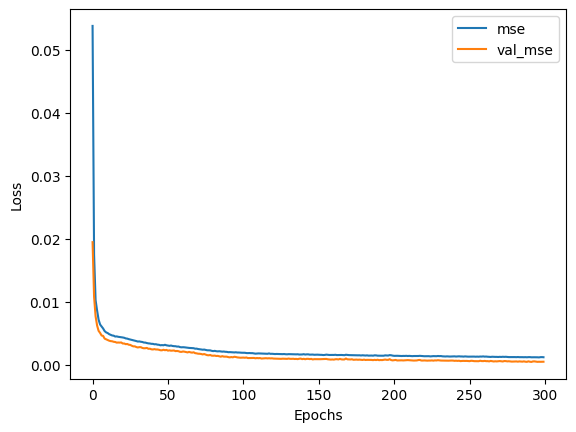

In [10]:
# Visualize training and validation loss
import matplotlib.pyplot as plt
lstm_train_loss = lstm_history.history['loss']
lstm_val_loss = lstm_history.history['val_loss']
plt.plot(lstm_train_loss)
plt.plot(lstm_val_loss)
# plt.plot(lstm_history.history['mse'])
# plt.plot(lstm_history.history['val_mse'])
plt.legend(['mse','val_mse'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [11]:
# model.save("LSTM_AE_trained_12_ts5.keras")

In [12]:
# from keras.saving import load_model
# from tensorflow.keras.models import load_model
# model = load_model("LSTM_AE_trained_12_ts5.keras")


#### Prediction Based on Training Bearings

In [13]:
# Predict on valudation test set
from sklearn.metrics import mean_absolute_percentage_error
## validation result list

val_pred_list = {} # we can visulize the prediction trend
val_mse_list = {}
val_mae_list = {}
for bearing in fold_train:
    val_pred_list[bearing] = model.predict(val_3D_list[bearing])
    val_mse_list[bearing] = np.mean(np.square(val_pred_list[bearing] - val_3D_list[bearing]), axis=(1,2))
    val_mae_list[bearing] = np.mean(np.abs(val_pred_list[bearing] - val_3D_list[bearing]), axis=(1,2))


39/39 [==============================] - 0s 2ms/step


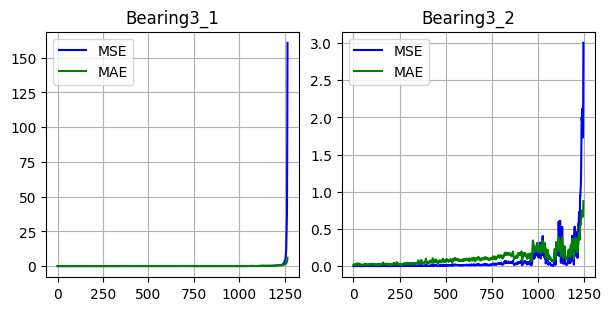

In [14]:
## Visulization
import matplotlib.pyplot as plt
## 2 bearings for development
fig, axs = plt.subplots(1,2, figsize=(6,3), layout='constrained')  
for i, ax in enumerate(axs.flat):
    ax.plot(val_mse_list[fold_train[i]], color='blue', label='MSE')
    ax.plot(val_mae_list[fold_train[i]], color='green', label='MAE')
    ax.set_title(fold_train[i])
    ax.legend()
    ax.grid(True)
    # ax.set_ylim(-0.005,0.06)
plt.show()

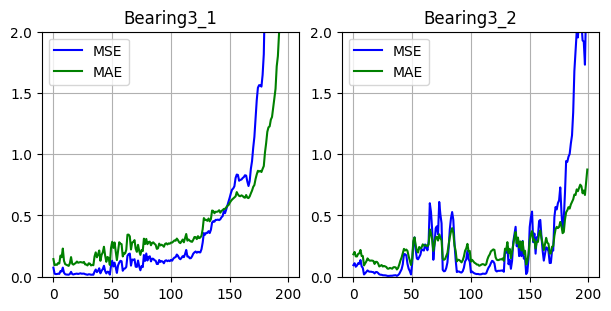

In [15]:
## Visulization
import matplotlib.pyplot as plt
## 2 bearings for development
fig, axs = plt.subplots(1,2, figsize=(6,3), layout='constrained')  
for i, ax in enumerate(axs.flat):
    ax.plot(val_mse_list[fold_train[i]][-200:], color='blue', label='MSE')
    ax.plot(val_mae_list[fold_train[i]][-200:], color='green', label='MAE')
    ax.set_title(fold_train[i])
    ax.legend()
    ax.grid(True)
    ax.set_ylim(-0.005,2)
plt.show()

In [16]:
## average 
ts_avg = 5
val_mse_avg_list = {}
val_mae_avg_list = {}
for bearing in fold_train:
    val_mse_avg_list[bearing] = [np.mean(val_mse_list[bearing][i:i+ts_avg]) for i in range(len(val_mse_list[bearing])-ts_avg)]
    val_mae_avg_list[bearing] = [np.mean(val_mae_list[bearing][i:i+ts_avg]) for i in range(len(val_mae_list[bearing])-ts_avg)]    

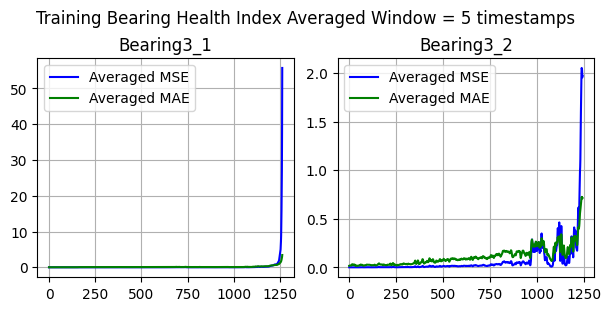

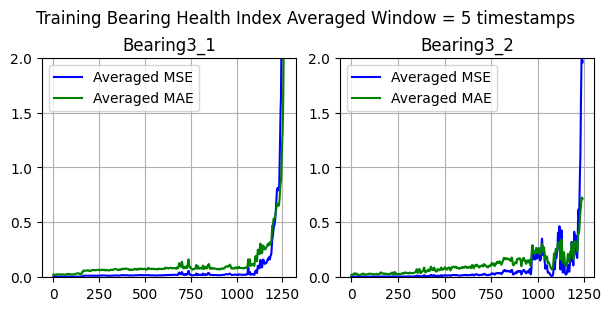

In [17]:
## Visulization
import matplotlib.pyplot as plt
## 2 bearings for development
fig, axs = plt.subplots(1,2, figsize=(6,3), layout='constrained')  
for i, ax in enumerate(axs.flat):
    ax.plot(val_mse_avg_list[fold_train[i]], color='blue', label='Averaged MSE')
    ax.plot(val_mae_avg_list[fold_train[i]], color='green', label='Averaged MAE')
    ax.set_title(fold_train[i])
    ax.legend()
    ax.grid(True)
    # ax.set_ylim(-0.005,2)
plt.suptitle(f'Training Bearing Health Index Averaged Window = {ts_avg} timestamps')
plt.show()

## Visulization
import matplotlib.pyplot as plt
## 2 bearings for development
fig, axs = plt.subplots(1,2, figsize=(6,3), layout='constrained')  
for i, ax in enumerate(axs.flat):
    ax.plot(val_mse_avg_list[fold_train[i]], color='blue', label='Averaged MSE')
    ax.plot(val_mae_avg_list[fold_train[i]], color='green', label='Averaged MAE')
    ax.set_title(fold_train[i])
    ax.legend()
    ax.grid(True)
    ax.set_ylim(-0.005,2)
plt.suptitle(f'Training Bearing Health Index Averaged Window = {ts_avg} timestamps')
plt.show()

Index(['Fr_o(Horizontal)', 'Fr_o(Vertical)', 'Fif_o(Horizontal)',
       'Fif_o(Vertical)', 'Fof_o(Horizontal)', 'Fof_o(Vertical)',
       'Fbf_o(Horizontal)', 'Fbf_o(Vertical)', 'Fcf_o(Horizontal)',
       'Fcf_o(Vertical)', 'Horizontal RMS', 'Vertical RMS'],
      dtype='object')
(1267, 3, 12)


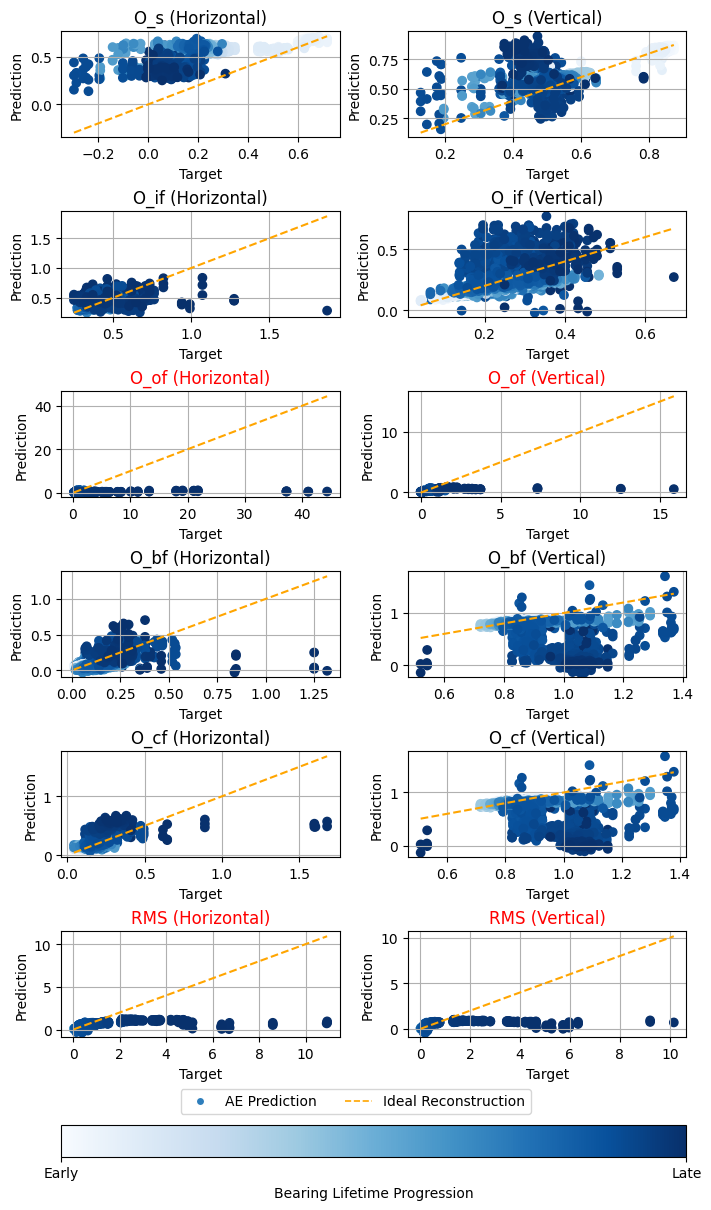

In [18]:
## visulize the trend as scatter
## totally 12 features 
from matplotlib.backends.backend_pdf import PdfPages
print(train_list[fold_train[0]].columns)
print(val_pred_list[fold_train[0]].shape) # data points, windows, features

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Get existing colormap objects for different windows
cmap = ['Blues','Greens','Reds']# but we only use one for clarity
subtitle = ['O_s (Horizontal)', 'O_s (Vertical)', 'O_if (Horizontal)', 'O_if (Vertical)', 'O_of (Horizontal)', 'O_of (Vertical)', 
            'O_bf (Horizontal)', 'O_bf (Vertical)', 'O_cf (Horizontal)', 'O_cf (Vertical)', 'RMS (Horizontal)', 'RMS (Vertical)']

pdf_filename = "Results/Bearing 3_1 Reconstruction legend.pdf"
with PdfPages(pdf_filename) as pdf:
    ## For bearing 1 (3_1), 12 feature
    fig, axs = plt.subplots(6,2, figsize=(7,12), layout='constrained')  
    for i, ax in enumerate(axs.flat):
        for w in range(3): # for each point in a window 
            # x actual, y prediction
            ax.scatter(val_3D_list[fold_train[0]][:,w,i], val_pred_list[fold_train[0]][:,w,i], #label=f'Window {w+1}',
                       # color = ['blue','green','red'][w])
                       c=np.linspace(0, 1, val_pred_list[fold_train[0]].shape[0]), cmap=cmap[0])
        ax.plot([np.min(val_3D_list[fold_train[0]][:,:,i]),np.max(val_3D_list[fold_train[0]][:,:,i])],
               [np.min(val_3D_list[fold_train[0]][:,:,i]),np.max(val_3D_list[fold_train[0]][:,:,i])],
               '--', color = 'orange')
        ax.set_title(subtitle[i])
        if i in [4,5,10,11]:
            ax.set_title(subtitle[i], color = 'red')
        ax.grid(True)
        ax.set_xlabel('Target')
        ax.set_ylabel('Prediction')

    # Legend for ideal reconstruction line
    ideal_line = Line2D([0], [0],linestyle='--',color='orange',linewidth=1.2,label='Ideal Reconstruction')
    # Legend for AE prediction scatter
    ae_scatter = Line2D([0], [0],marker='o',color='w', markerfacecolor=plt.cm.Blues(0.7),label='AE Prediction')
        # markersize=6,

    fig.legend(handles=[ae_scatter, ideal_line],loc='lower center',bbox_to_anchor=(0.5, 0.07),ncol=2,frameon=True)

    # -----  colorbars in the botoom -----
    norm = mpl.colors.Normalize(vmin=0, vmax=1)
    
    sm = plt.cm.ScalarMappable(cmap=cmap[0],norm=norm)

    sm.set_array([])

    cbar = fig.colorbar(sm,
        ax=axs[5, :],      # both subplots in this row
        orientation='horizontal',fraction=0.3,pad=0.4)

    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(['Early', 'Late'])

    cbar.set_label('Bearing Lifetime Progression')

    pdf.savefig()
plt.show()

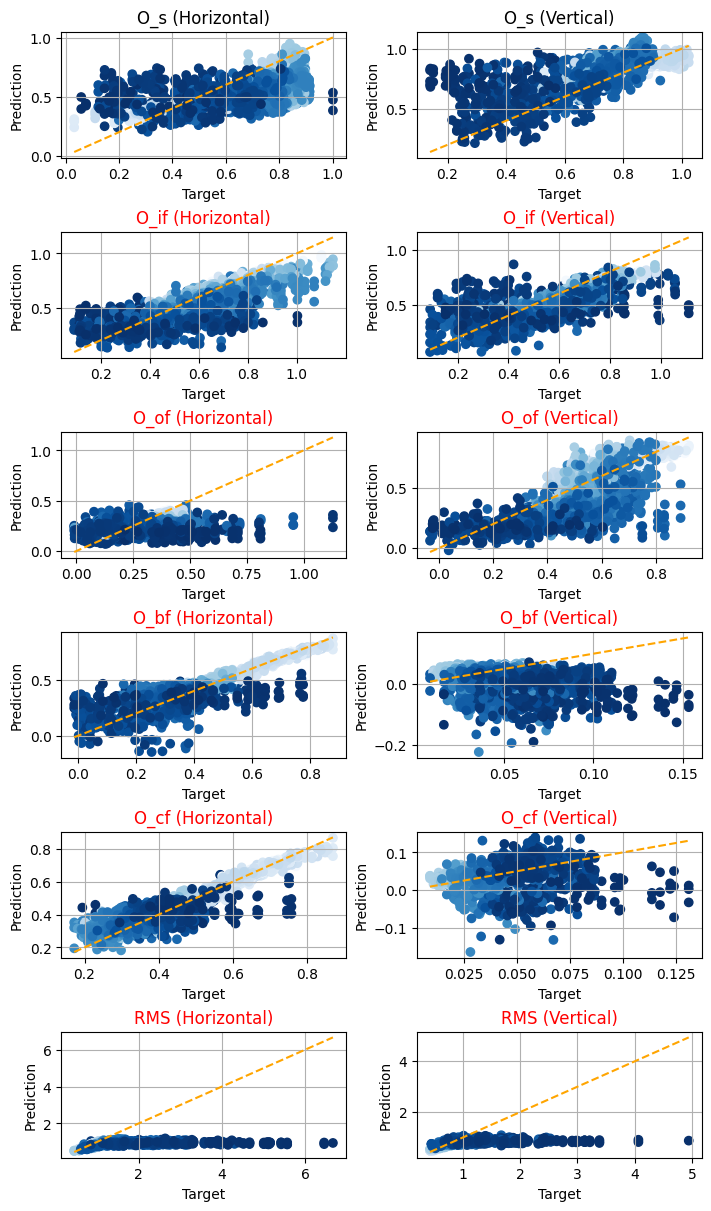

In [19]:
## visulize the trend as scatter
## totally 12 features 
import matplotlib as mpl
import matplotlib.pyplot as plt
# Get existing colormap objects for different windows
cmap = ['Blues','Greens','Reds']# but we only use one for clarity
subtitle = ['O_s (Horizontal)', 'O_s (Vertical)', 'O_if (Horizontal)', 'O_if (Vertical)', 'O_of (Horizontal)', 'O_of (Vertical)', 
            'O_bf (Horizontal)', 'O_bf (Vertical)', 'O_cf (Horizontal)', 'O_cf (Vertical)', 'RMS (Horizontal)', 'RMS (Vertical)']

pdf_filename = "Results/Bearing 3_2 Reconstruction.pdf"
with PdfPages(pdf_filename) as pdf:
    ## For bearing 2 (3_2), 12 feature
    b=1
    fig, axs = plt.subplots(6,2, figsize=(7,12), layout='constrained')  
    for i, ax in enumerate(axs.flat):
        for w in range(3): # for each point in a window 
            # x actual, y prediction
            ax.scatter(val_3D_list[fold_train[b]][:,w,i], val_pred_list[fold_train[b]][:,w,i], #label=f'Window {w+1}',
                       # color = ['blue','green','red'][w])
                       c=np.linspace(0, 1, val_pred_list[fold_train[b]].shape[0]), cmap=cmap[0])
        ax.plot([np.min(val_3D_list[fold_train[b]][:,:,i]),np.max(val_3D_list[fold_train[b]][:,:,i])],
               [np.min(val_3D_list[fold_train[b]][:,:,i]),np.max(val_3D_list[fold_train[b]][:,:,i])],
               '--', color = 'orange')
        ax.set_title(subtitle[i])
        if i in range(2,13): # 
            ax.set_title(subtitle[i], color = 'red')
        ax.grid(True)
        ax.set_xlabel('Target')
        ax.set_ylabel('Prediction')     
    pdf.savefig()
plt.show()

### Transfer Learning

In [20]:
## Partition the tuning sets 
## Shuffle the tuning sets 
from sklearn.utils import shuffle
print("test bearing 1",test_3D_list[fold_test[0]].shape)
test_3D_tune_US_list = {}
test_3D_tune_list = {}
test_3D_test_US_list = {}
for bearing in fold_test:
    test_3D_tune_US_list[bearing] = test_3D_list[bearing][:60,:,:]
    test_3D_test_US_list[bearing] = test_3D_list[bearing][60:,:,:]
    test_3D_tune_list[bearing] = shuffle(test_3D_tune_US_list[bearing])

print("test bearing 1, tuning set",test_3D_tune_US_list[fold_test[0]].shape)
print("test bearing 1, shuffled tuning set",test_3D_tune_list[fold_test[0]].shape)
print("test bearing 1, testing set",test_3D_test_US_list[fold_test[0]].shape)

test bearing 1 (369, 3, 12)
test bearing 1, tuning set (60, 3, 12)
test bearing 1, shuffled tuning set (60, 3, 12)
test bearing 1, testing set (309, 3, 12)


#### Validation

In [21]:
from keras.models import clone_model
## validation set 
d = 0
bearing = fold_test[d]
# Clone the model
model_val = clone_model(model)
# Copy weights from the original model to the cloned model
model_val.set_weights(model.get_weights())
# Compile the cloned model
initial_learning_rate = 0.0005
lr_schedule = keras.optimizers.schedules.CosineDecay(
                initial_learning_rate,
                decay_steps=150,
                alpha=0.01) 
opt = keras.optimizers.Adam(learning_rate=lr_schedule)

model_val.compile(optimizer=opt, loss='mse', metrics=['mae'])
# model_val.summary()
# Fitting the LSTM to the Training set
time_callback1=TimeHistory()
lstm_history1=model_val.fit(test_3D_tune_list[bearing], test_3D_tune_list[bearing], epochs = 200, batch_size = 12, validation_split=0.1, shuffle=True, callbacks=[time_callback1])
print(sum(time_callback1.times))

Epoch 1/200
5/5 [==============================] - 4s 174ms/step - loss: 0.0420 - mae: 0.1532 - val_loss: 0.0279 - val_mae: 0.1265
Epoch 2/200
5/5 [==============================] - 0s 15ms/step - loss: 0.0317 - mae: 0.1311 - val_loss: 0.0191 - val_mae: 0.1034
Epoch 3/200
5/5 [==============================] - 0s 14ms/step - loss: 0.0228 - mae: 0.1090 - val_loss: 0.0135 - val_mae: 0.0901
Epoch 4/200
5/5 [==============================] - 0s 15ms/step - loss: 0.0186 - mae: 0.0995 - val_loss: 0.0091 - val_mae: 0.0750
Epoch 5/200
5/5 [==============================] - 0s 14ms/step - loss: 0.0131 - mae: 0.0861 - val_loss: 0.0066 - val_mae: 0.0624
Epoch 6/200
5/5 [==============================] - 0s 14ms/step - loss: 0.0109 - mae: 0.0787 - val_loss: 0.0055 - val_mae: 0.0537
Epoch 7/200
5/5 [==============================] - 0s 14ms/step - loss: 0.0097 - mae: 0.0738 - val_loss: 0.0049 - val_mae: 0.0482
Epoch 8/200
5/5 [==============================] - 0s 14ms/step - loss: 0.0092 - mae: 0.0

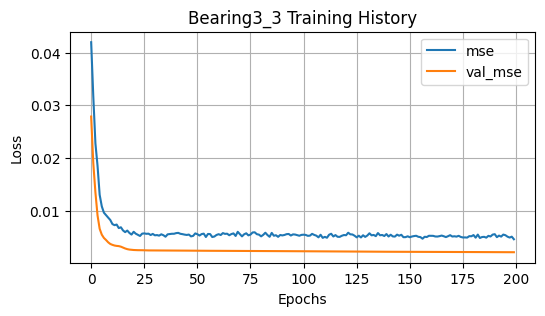

In [22]:
# Visualize training and validation loss
import matplotlib.pyplot as plt
lstm_train_loss = lstm_history1.history['loss']
lstm_val_loss = lstm_history1.history['val_loss']
# lstm_val_loss = lstm_history1.history['val_loss']
plt.figure(figsize=(6,3))
plt.plot(lstm_train_loss)
plt.plot(lstm_val_loss)
# plt.plot(lstm_history.history['mse'])
# plt.plot(lstm_history.history['val_mse'])
plt.title(f'{bearing} Training History')
plt.legend(['mse','val_mse'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid()
plt.show()

10/10 [==============================] - 1s 2ms/step


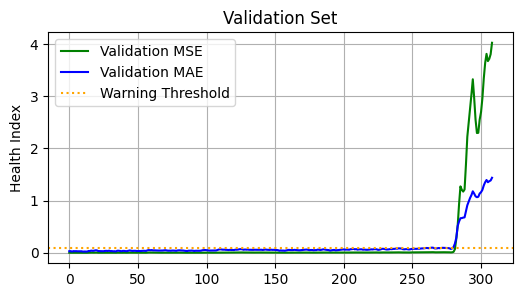

In [23]:
# Predict on valudation test set
from sklearn.metrics import mean_absolute_percentage_error
X_validation_pred = model_val.predict(test_3D_test_US_list[bearing])
thres = 0.1
## creat Health Index based on the validation set (normalize the HI to [0,1])
mse1 = np.mean(np.square(X_validation_pred - test_3D_test_US_list[bearing]), axis=(1,2))
mae1 = np.mean(np.abs(X_validation_pred - test_3D_test_US_list[bearing]), axis=(1,2))

# HI = (mse - np.min(mse)) / (np.max(mse) - np.min(mse)) 
import matplotlib.pyplot as plt
plt.figure(figsize=(6,3))
plt.plot(mse1, color='green', label='Validation MSE')
plt.plot(mae1, color='blue', label='Validation MAE')
plt.axhline(thres, color='orange', linestyle=':', label='Warning Threshold')
# plt.axvline(len(X_val1)-ts, color='red', linestyle=':', label='Dataset Partition')
plt.ylabel('Health Index')
plt.title('Validation Set')
plt.legend()
plt.grid(True)

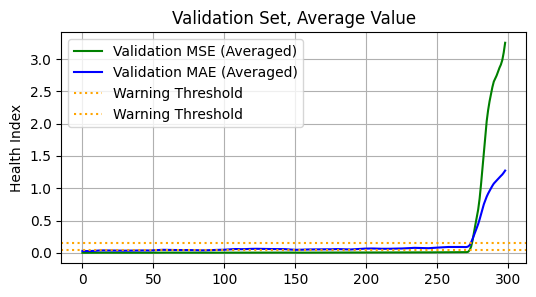

In [24]:
## avg values
thres1 = 0.15
thres2 = 0.05
ts_avg = 10 # avg window
mse1_avg = np.array([])
mae1_avg = np.array([])
for i in range(len(mse1)-ts_avg):
    mse1_avg = np.append(mse1_avg, np.mean(mse1[i:i+ts_avg]))
    mae1_avg = np.append(mae1_avg, np.mean(mae1[i:i+ts_avg]))
# print(mse1_avg)
# print(mae1_avg)
import matplotlib.pyplot as plt
plt.figure(figsize=(6,3))
plt.plot(mse1_avg, color='green', label='Validation MSE (Averaged)')
plt.plot(mae1_avg, color='blue', label='Validation MAE (Averaged)')
plt.axhline(thres1, color='orange', linestyle=':', label='Warning Threshold')
plt.axhline(thres2, color='orange', linestyle=':', label='Warning Threshold')
# plt.axvline(len(X_val1)-ts, color='red', linestyle=':', label='Dataset Partition')
plt.ylabel('Health Index')
plt.title('Validation Set, Average Value')
plt.legend()
plt.grid(True)

12/12 [==============================] - 0s 2ms/step


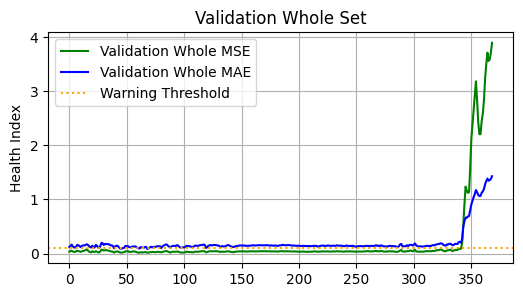

In [25]:
# Predict on valudation test set
from sklearn.metrics import mean_absolute_percentage_error
X_validation_pred_whole = model.predict(test_3D_list[bearing])
thres = 0.1
## creat Health Index based on the validation set (normalize the HI to [0,1])
mse1_whole = np.mean(np.square(X_validation_pred_whole - test_3D_list[bearing]), axis=(1,2))
mae1_whole = np.mean(np.abs(X_validation_pred_whole - test_3D_list[bearing]), axis=(1,2))

# HI = (mse - np.min(mse)) / (np.max(mse) - np.min(mse)) 
import matplotlib.pyplot as plt
plt.figure(figsize=(6,3))
plt.plot(mse1_whole, color='green', label='Validation Whole MSE')
plt.plot(mae1_whole, color='blue', label='Validation Whole MAE')
plt.axhline(thres, color='orange', linestyle=':', label='Warning Threshold')
# plt.axvline(len(X_val1)-ts, color='red', linestyle=':', label='Dataset Partition')
plt.ylabel('Health Index')
plt.title('Validation Whole Set')
plt.legend()
plt.grid(True)


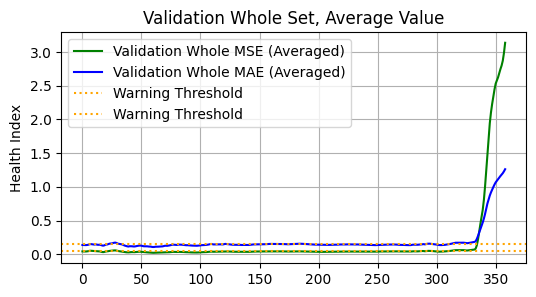

In [26]:
## avg values
thres1 = 0.15
thres2 = 0.05
ts_avg = 10 # avg window
mse1_avg_whole = np.array([])
mae1_avg_whole = np.array([])
for i in range(len(mse1_whole)-ts_avg):
    mse1_avg_whole = np.append(mse1_avg_whole, np.mean(mse1_whole[i:i+ts_avg]))
    mae1_avg_whole = np.append(mae1_avg_whole, np.mean(mae1_whole[i:i+ts_avg]))
# print(mse1_avg)
# print(mae1_avg)
import matplotlib.pyplot as plt
plt.figure(figsize=(6,3))
plt.plot(mse1_avg_whole, color='green', label='Validation Whole MSE (Averaged)')
plt.plot(mae1_avg_whole, color='blue', label='Validation Whole MAE (Averaged)')
plt.axhline(thres1, color='orange', linestyle=':', label='Warning Threshold')
plt.axhline(thres2, color='orange', linestyle=':', label='Warning Threshold')
# plt.axvline(len(X_val1)-ts, color='red', linestyle=':', label='Dataset Partition')
plt.ylabel('Health Index')
plt.title('Validation Whole Set, Average Value')
plt.legend()
plt.grid(True)

#### Test 1, 2

In [27]:
from keras.models import clone_model

d = [1,2]
model_test_list = {}
time_callback_test_list = {}
history_lstm_test_list = {}
for bearing in fold_test[d]:
    # Clone the model
    model_test_list[bearing] = clone_model(model)
    # Copy weights from the original model to the cloned model
    model_test_list[bearing].set_weights(model.get_weights())
    ## hyper-parameters
    initial_learning_rate = 0.0005
    lr_schedule = keras.optimizers.schedules.CosineDecay(
                    initial_learning_rate,
                    decay_steps=100,
                    alpha=0.01) 
    opt = keras.optimizers.Adam(learning_rate=lr_schedule)
    # Compile the cloned model
    model_test_list[bearing].compile(optimizer=opt, loss='mse', metrics=['mae'])
    # model_val.summary()
    # Fitting the LSTM to the Training set
    time_callback_test_list[bearing] = TimeHistory()
    history_lstm_test_list[bearing] = model_test_list[bearing].fit(test_3D_tune_list[bearing], test_3D_tune_list[bearing],
                                                                   epochs = 200, batch_size = 12, validation_split=0.1, 
                                                                   shuffle=True, callbacks=[time_callback_test_list[bearing]])
                                                                   
for bearing in fold_test[d]: 
    print(sum(time_callback_test_list[bearing].times))

Epoch 1/200
5/5 [==============================] - 4s 167ms/step - loss: 0.3989 - mae: 0.4694 - val_loss: 0.3081 - val_mae: 0.4122
Epoch 2/200
5/5 [==============================] - 0s 14ms/step - loss: 0.3160 - mae: 0.4002 - val_loss: 0.2290 - val_mae: 0.3183
Epoch 3/200
5/5 [==============================] - 0s 13ms/step - loss: 0.2615 - mae: 0.3472 - val_loss: 0.1904 - val_mae: 0.2846
Epoch 4/200
5/5 [==============================] - 0s 13ms/step - loss: 0.2277 - mae: 0.3318 - val_loss: 0.1477 - val_mae: 0.2671
Epoch 5/200
5/5 [==============================] - 0s 13ms/step - loss: 0.1777 - mae: 0.3042 - val_loss: 0.1186 - val_mae: 0.2525
Epoch 6/200
5/5 [==============================] - 0s 12ms/step - loss: 0.1544 - mae: 0.2941 - val_loss: 0.0940 - val_mae: 0.2351
Epoch 7/200
5/5 [==============================] - 0s 14ms/step - loss: 0.1203 - mae: 0.2628 - val_loss: 0.0743 - val_mae: 0.2075
Epoch 8/200
5/5 [==============================] - 0s 13ms/step - loss: 0.0982 - mae: 0.2

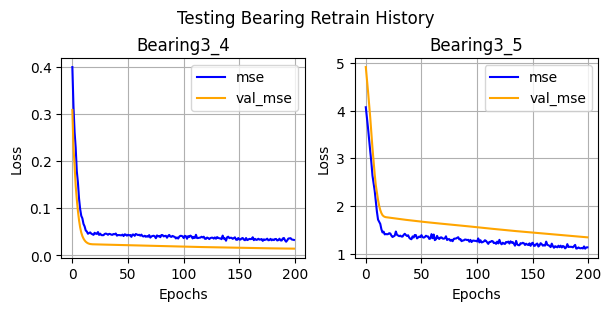

In [28]:
# Visualize training and validation loss
# two testing bearings
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1,2, figsize=(6,3), layout='constrained')  
for i, ax in enumerate(axs.flat):
    bearing = fold_test[d[i]]
    ax.plot(history_lstm_test_list[bearing].history['loss'], color='blue', label='mse')
    ax.plot(history_lstm_test_list[bearing].history['val_loss'], color='orange', label='val_mse')
    ax.set_title(bearing)
    ax.legend()
    ax.grid(True)
    # ax.set_ylim(-0.005,0.06)
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss')
plt.suptitle('Testing Bearing Retrain History')
plt.show()


In [29]:
## retrain 2 after visulization
d = [2]
# model_test_list = {}
# time_callback_test_list = {}
# history_lstm_test_list = {}
for bearing in fold_test[d]:
    # Clone the model
    model_test_list[bearing] = clone_model(model)
    # Copy weights from the original model to the cloned model
    model_test_list[bearing].set_weights(model.get_weights())
    ## hyper-parameters
    initial_learning_rate = 0.0005
    lr_schedule = keras.optimizers.schedules.CosineDecay(
                    initial_learning_rate,
                    decay_steps=1500,
                    alpha=0.01) 
    opt = keras.optimizers.Adam(learning_rate=lr_schedule)
    # Compile the cloned model
    model_test_list[bearing].compile(optimizer=opt, loss='mse', metrics=['mae'])
    # model_val.summary()
    # Fitting the LSTM to the Training set
    time_callback_test_list[bearing] = TimeHistory()
    history_lstm_test_list[bearing] = model_test_list[bearing].fit(test_3D_tune_list[bearing], test_3D_tune_list[bearing],
                                                                   epochs = 200, batch_size = 12, validation_split=0.1, 
                                                                   shuffle=True, callbacks=[time_callback_test_list[bearing]])
                                                                   
for bearing in fold_test[d]: 
    print(sum(time_callback_test_list[bearing].times))

Epoch 1/200
5/5 [==============================] - 4s 171ms/step - loss: 4.0896 - mae: 1.1916 - val_loss: 4.8810 - val_mae: 1.2909
Epoch 2/200
5/5 [==============================] - 0s 16ms/step - loss: 3.8504 - mae: 1.1554 - val_loss: 4.6344 - val_mae: 1.2618
Epoch 3/200
5/5 [==============================] - 0s 13ms/step - loss: 3.6180 - mae: 1.1242 - val_loss: 4.3750 - val_mae: 1.2218
Epoch 4/200
5/5 [==============================] - 0s 13ms/step - loss: 3.3816 - mae: 1.0801 - val_loss: 4.0977 - val_mae: 1.1667
Epoch 5/200
5/5 [==============================] - 0s 13ms/step - loss: 3.1281 - mae: 1.0325 - val_loss: 3.7852 - val_mae: 1.0971
Epoch 6/200
5/5 [==============================] - 0s 13ms/step - loss: 2.8456 - mae: 0.9885 - val_loss: 3.4297 - val_mae: 1.0117
Epoch 7/200
5/5 [==============================] - 0s 15ms/step - loss: 2.5524 - mae: 0.9085 - val_loss: 3.0705 - val_mae: 0.9315
Epoch 8/200
5/5 [==============================] - 0s 15ms/step - loss: 2.2297 - mae: 0.8

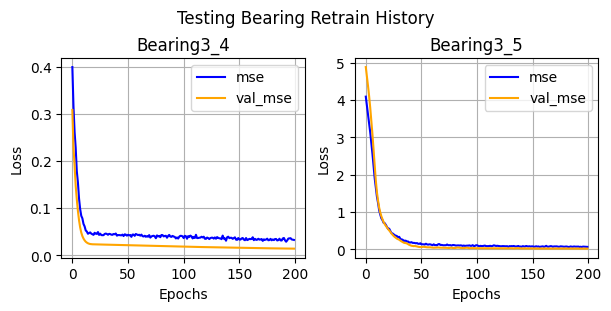

In [30]:
# Visualize training and validation loss
# two testing bearings
import matplotlib.pyplot as plt
d = [1,2]
fig, axs = plt.subplots(1,2, figsize=(6,3), layout='constrained')  
for i, ax in enumerate(axs.flat):
    bearing = fold_test[d[i]]
    ax.plot(history_lstm_test_list[bearing].history['loss'], color='blue', label='mse')
    ax.plot(history_lstm_test_list[bearing].history['val_loss'], color='orange', label='val_mse')
    ax.set_title(bearing)
    ax.legend()
    ax.grid(True)
    # ax.set_ylim(-0.005,0.06)
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss')
plt.suptitle('Testing Bearing Retrain History')
plt.show()


#### Prediction in the testing part (after one hour)

In [31]:
# Predict on testing set
# also visulize the validation set
from sklearn.metrics import mean_absolute_percentage_error

d = [1,2] # testing set
test_pred_list = {} # we can visulize the prediction trend
test_mse_list = {}
test_mae_list = {}
## validation set
bearing = fold_test[0] # 0, validation set
test_pred_list[bearing] = model_val.predict(test_3D_test_US_list[bearing])
test_mse_list[bearing] = np.mean(np.square(test_pred_list[bearing] - test_3D_test_US_list[bearing]), axis=(1,2))
test_mae_list[bearing] = np.mean(np.abs(test_pred_list[bearing] - test_3D_test_US_list[bearing]), axis=(1,2))
## testing set 
for bearing in fold_test[d]:
    
    test_pred_list[bearing] = model_test_list[bearing].predict(test_3D_test_US_list[bearing])
    test_mse_list[bearing] = np.mean(np.square(test_pred_list[bearing] - test_3D_test_US_list[bearing]), axis=(1,2))
    test_mae_list[bearing] = np.mean(np.abs(test_pred_list[bearing] - test_3D_test_US_list[bearing]), axis=(1,2))

2/2 [==============================] - 1s 4ms/step


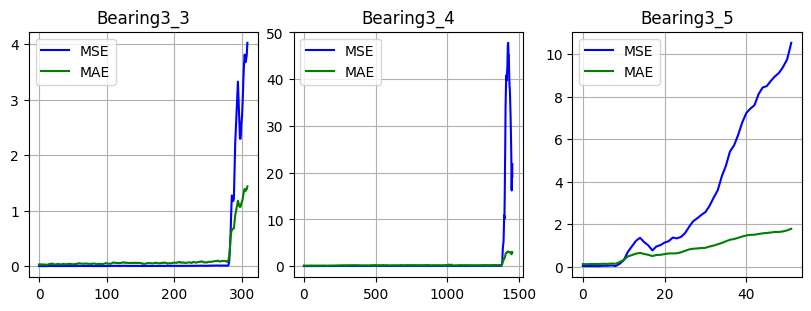

In [32]:
## Visulization
import matplotlib.pyplot as plt
## 3 bearing for transfer learning
fig, axs = plt.subplots(1,3, figsize=(8,3), layout='constrained')  
for i, ax in enumerate(axs.flat):
    ax.plot(test_mse_list[fold_test[i]], color='blue', label='MSE')
    ax.plot(test_mae_list[fold_test[i]], color='green', label='MAE')
    ax.set_title(fold_test[i])
    ax.legend()
    ax.grid(True)
    # ax.set_ylim(-0.005,0.06)
plt.show()

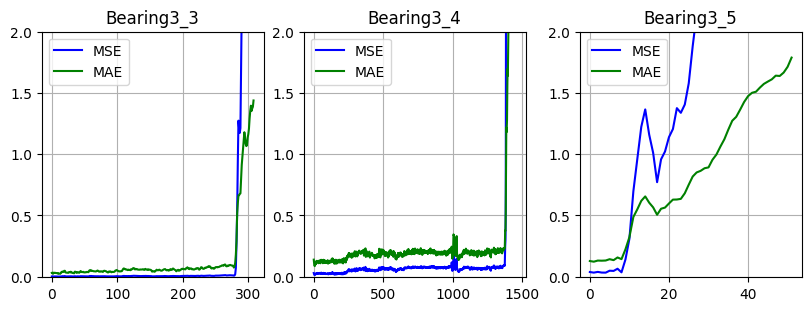

In [33]:
## Visulization
import matplotlib.pyplot as plt
## 3 bearing for transfer learning
fig, axs = plt.subplots(1,3, figsize=(8,3), layout='constrained')  
for i, ax in enumerate(axs.flat):
    ax.plot(test_mse_list[fold_test[i]], color='blue', label='MSE')
    ax.plot(test_mae_list[fold_test[i]], color='green', label='MAE')
    ax.set_title(fold_test[i])
    ax.legend()
    ax.grid(True)
    ax.set_ylim(-0.005,2)
plt.show()

In [34]:
## average 
ts_avg = 5
test_mse_avg_list = {}
test_mae_avg_list = {}
for bearing in fold_test:
    test_mse_avg_list[bearing] = [np.mean(test_mse_list[bearing][i:i+ts_avg]) for i in range(len(test_mse_list[bearing])-ts_avg)]
    test_mae_avg_list[bearing] = [np.mean(test_mae_list[bearing][i:i+ts_avg]) for i in range(len(test_mae_list[bearing])-ts_avg)]  

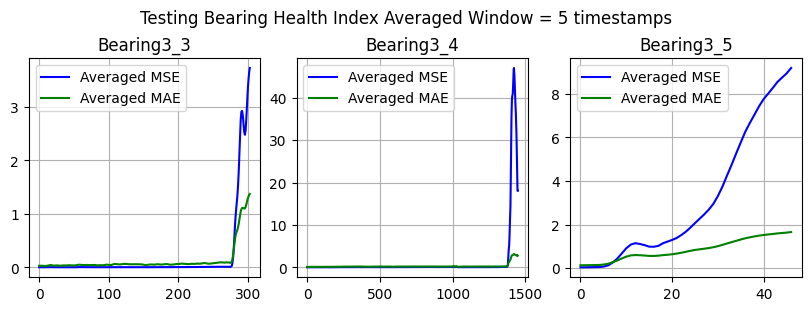

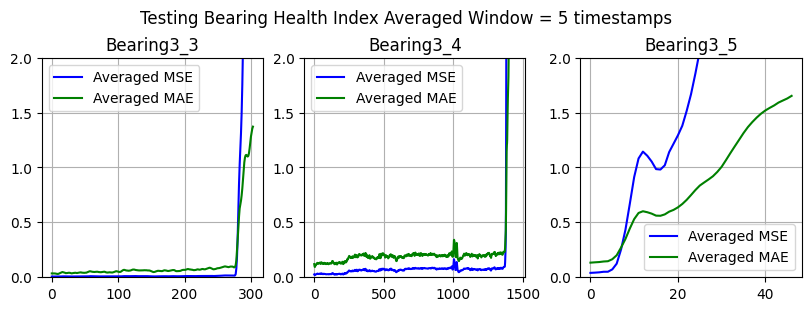

In [35]:
## Visulization
import matplotlib.pyplot as plt
## 3 bearing for transfer learning
fig, axs = plt.subplots(1,3, figsize=(8,3), layout='constrained')  
for i, ax in enumerate(axs.flat):
    ax.plot(test_mse_avg_list[fold_test[i]], color='blue', label='Averaged MSE')
    ax.plot(test_mae_avg_list[fold_test[i]], color='green', label='Averaged MAE')
    ax.set_title(fold_test[i])
    ax.legend()
    ax.grid(True)
    # ax.set_ylim(-0.005,0.06)
plt.suptitle(f'Testing Bearing Health Index Averaged Window = {ts_avg} timestamps')
plt.show()

fig, axs = plt.subplots(1,3, figsize=(8,3), layout='constrained')  
for i, ax in enumerate(axs.flat):
    ax.plot(test_mse_avg_list[fold_test[i]], color='blue', label='Averaged MSE')
    ax.plot(test_mae_avg_list[fold_test[i]], color='green', label='Averaged MAE')
    ax.set_title(fold_test[i])
    ax.legend()
    ax.grid(True)
    ax.set_ylim(-0.005,2)
plt.suptitle(f'Testing Bearing Health Index Averaged Window = {ts_avg} timestamps')
plt.show()

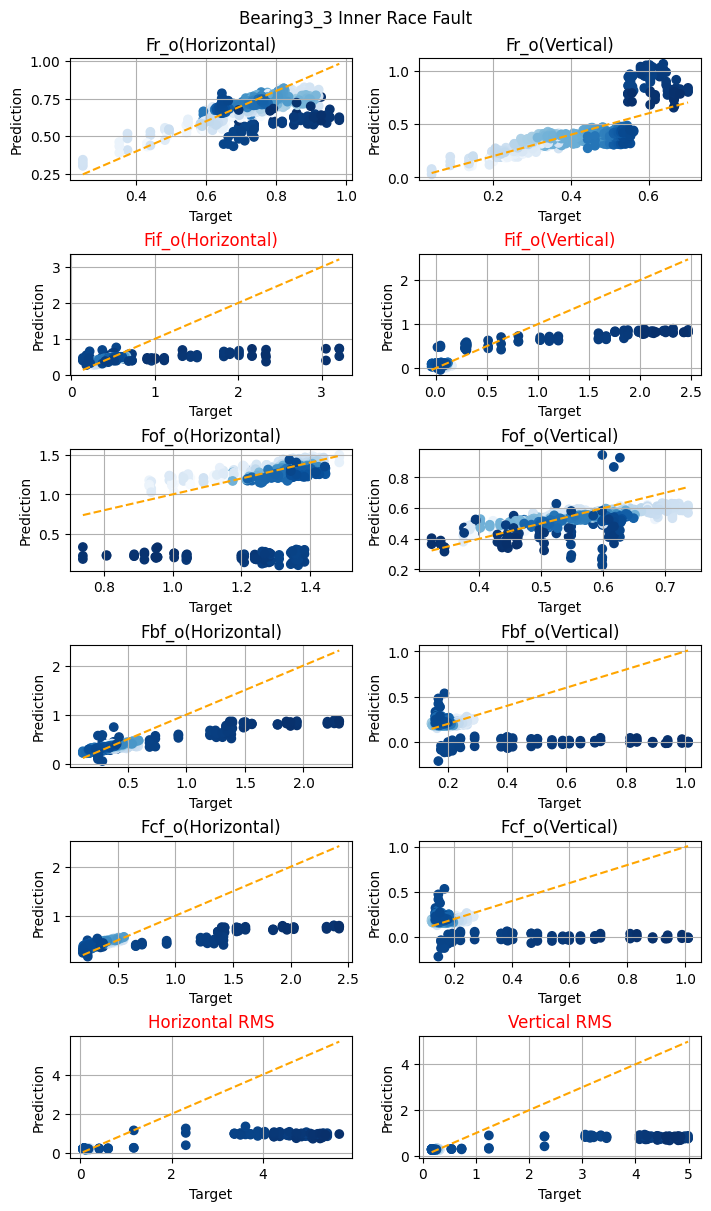

In [36]:
## visulize the trend as scatter
## totally 12 features 
import matplotlib as mpl
import matplotlib.pyplot as plt
# Get existing colormap objects for different windows
cmap = ['Blues','Greens','Reds']# but we only use one for clarity
## For bearing 3 (3_3), 12 feature
b=0
prediction_list = test_pred_list
target_list = test_3D_test_US_list
bearing_list = fold_test
dataframe_list = test_list
fig, axs = plt.subplots(6,2, figsize=(7,12), layout='constrained')  
for i, ax in enumerate(axs.flat):
    for w in range(3): # for each point in a window 
        # x actual, y prediction
        ax.scatter(target_list[bearing_list[b]][:,w,i], prediction_list[bearing_list[b]][:,w,i], #label=f'Window {w+1}',
                   # color = ['blue','green','red'][w])
                   c=np.linspace(0, 1, prediction_list[bearing_list[b]].shape[0]), cmap=cmap[0])
    ax.plot([np.min(target_list[bearing_list[b]][:,:,i]),np.max(target_list[bearing_list[b]][:,:,i])],
           [np.min(target_list[bearing_list[b]][:,:,i]),np.max(target_list[bearing_list[b]][:,:,i])],
           '--', color = 'orange')
    ax.set_title(dataframe_list[bearing_list[b]].columns[i])
    if i in [2,3,10,11]: # 
        ax.set_title(dataframe_list[bearing_list[b]].columns[i], color = 'red')
    ax.grid(True)
    ax.set_xlabel('Target')
    ax.set_ylabel('Prediction')
    # ax.set_ylim(-0.005,2)
    # if i%2!=0:
    #     ax.legend(loc='center left', bbox_to_anchor=(1.1, 0.5))
plt.suptitle(bearing_list[b]+' Inner Race Fault')        
plt.show()

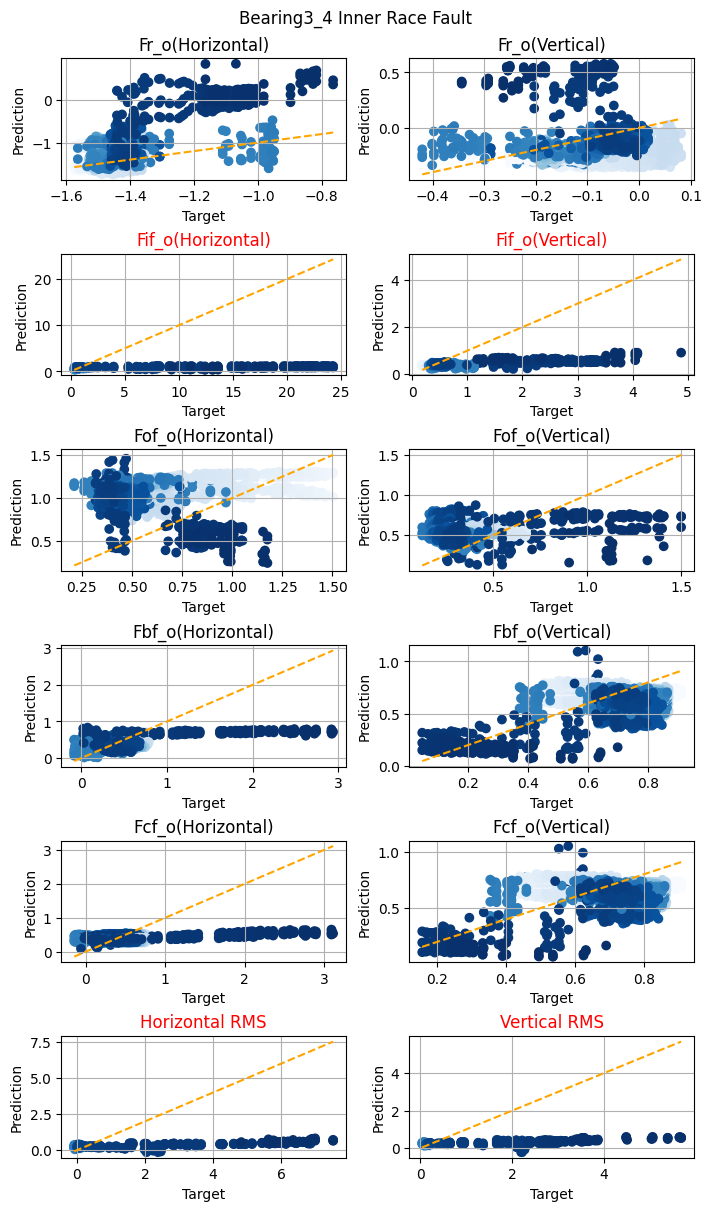

In [37]:
## visulize the trend as scatter
## totally 12 features 
import matplotlib as mpl
import matplotlib.pyplot as plt
# Get existing colormap objects for different windows
cmap = ['Blues','Greens','Reds']# but we only use one for clarity
## For bearing 4 (3_4), 12 feature
b=1
prediction_list = test_pred_list
target_list = test_3D_test_US_list
bearing_list = fold_test
dataframe_list = test_list
fig, axs = plt.subplots(6,2, figsize=(7,12), layout='constrained')  
for i, ax in enumerate(axs.flat):
    for w in range(3): # for each point in a window 
        # x actual, y prediction
        ax.scatter(target_list[bearing_list[b]][:,w,i], prediction_list[bearing_list[b]][:,w,i], #label=f'Window {w+1}',
                   # color = ['blue','green','red'][w])
                   c=np.linspace(0, 1, prediction_list[bearing_list[b]].shape[0]), cmap=cmap[0])
    ax.plot([np.min(target_list[bearing_list[b]][:,:,i]),np.max(target_list[bearing_list[b]][:,:,i])],
           [np.min(target_list[bearing_list[b]][:,:,i]),np.max(target_list[bearing_list[b]][:,:,i])],
           '--', color = 'orange')
    ax.set_title(dataframe_list[bearing_list[b]].columns[i])
    if i in [2,3,10,11]: # 
        ax.set_title(dataframe_list[bearing_list[b]].columns[i], color = 'red')
    ax.grid(True)
    ax.set_xlabel('Target')
    ax.set_ylabel('Prediction')
    # ax.set_ylim(-0.005,2)
    # if i%2!=0:
    #     ax.legend(loc='center left', bbox_to_anchor=(1.1, 0.5))
plt.suptitle(bearing_list[b]+' Inner Race Fault')        
plt.show()

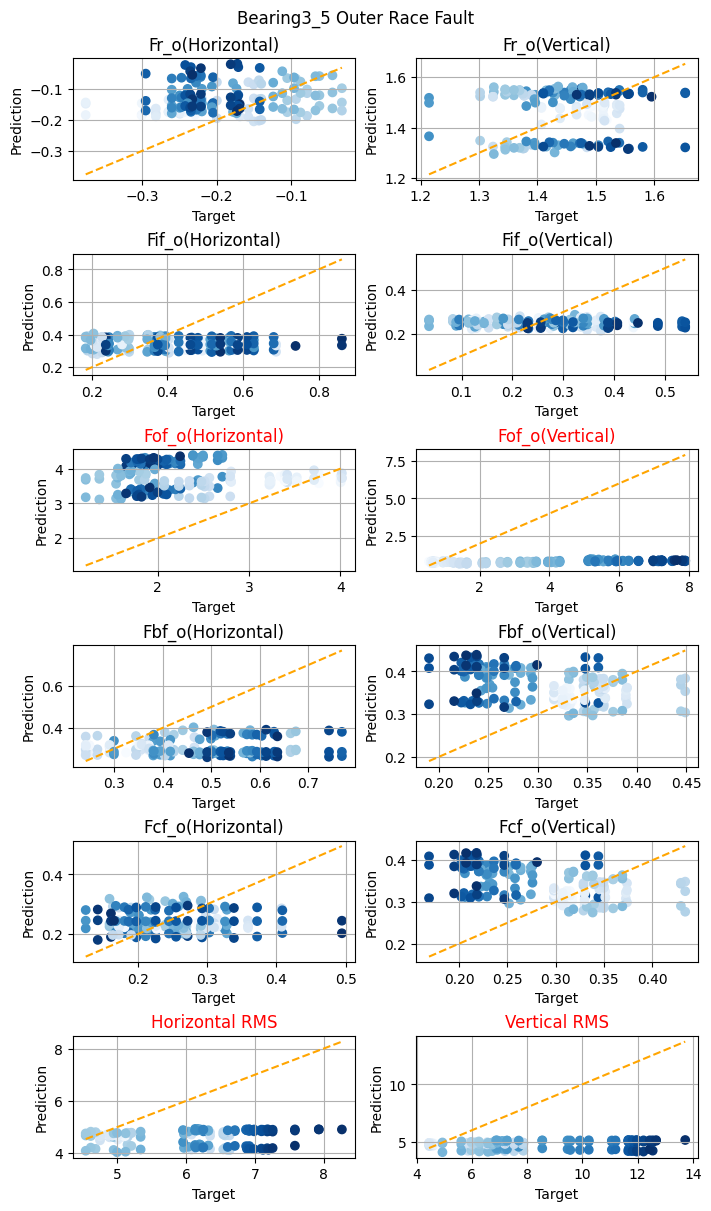

In [38]:
## visulize the trend as scatter
## totally 12 features 
import matplotlib as mpl
import matplotlib.pyplot as plt
# Get existing colormap objects for different windows
cmap = ['Blues','Greens','Reds']# but we only use one for clarity
## For bearing 3 (3_3), 12 feature
b=2
prediction_list = test_pred_list
target_list = test_3D_test_US_list
bearing_list = fold_test
dataframe_list = test_list
fig, axs = plt.subplots(6,2, figsize=(7,12), layout='constrained')  
for i, ax in enumerate(axs.flat):
    for w in range(3): # for each point in a window 
        # x actual, y prediction
        ax.scatter(target_list[bearing_list[b]][:,w,i], prediction_list[bearing_list[b]][:,w,i], #label=f'Window {w+1}',
                   # color = ['blue','green','red'][w])
                   c=np.linspace(0, 1, prediction_list[bearing_list[b]].shape[0]), cmap=cmap[0])
    ax.plot([np.min(target_list[bearing_list[b]][:,:,i]),np.max(target_list[bearing_list[b]][:,:,i])],
           [np.min(target_list[bearing_list[b]][:,:,i]),np.max(target_list[bearing_list[b]][:,:,i])],
           '--', color = 'orange')
    ax.set_title(dataframe_list[bearing_list[b]].columns[i])
    if i in [4,5,10,11]: # 
        ax.set_title(dataframe_list[bearing_list[b]].columns[i], color = 'red')
    ax.grid(True)
    ax.set_xlabel('Target')
    ax.set_ylabel('Prediction')
    # ax.set_ylim(-0.005,2)
    # if i%2!=0:
    #     ax.legend(loc='center left', bbox_to_anchor=(1.1, 0.5))
plt.suptitle(bearing_list[b]+' Outer Race Fault')        
plt.show()

#### Prediction with the whole dataset

In [39]:
# Predict on whole training set
from sklearn.metrics import mean_absolute_percentage_error
## change: result list
whole_list = train_3D_list # input into the model
bearing_list = fold_train

## change: model
whole_pred_list = {} # we can visulize the prediction trend
whole_mse_list = {}
whole_mae_list = {}
for bearing in bearing_list:
    whole_pred_list[bearing] = model.predict(whole_list[bearing])
    whole_mse_list[bearing] = np.mean(np.square(whole_pred_list[bearing] - whole_list[bearing]), axis=(1,2))
    whole_mae_list[bearing] = np.mean(np.abs(whole_pred_list[bearing] - whole_list[bearing]), axis=(1,2))

## change: get the list
fulltrain_pred_list = whole_pred_list
fulltrain_mse_list = whole_mse_list
fulltrain_mae_list = whole_mae_list

39/39 [==============================] - 0s 2ms/step


In [40]:
# Predict on whole testing set
from sklearn.metrics import mean_absolute_percentage_error
## change: result list
whole_list = test_3D_list # input into the model
bearing_list = fold_test
d = [1,2] # testing set

## change: **model**, validation set
whole_pred_list = {} # we can visulize the prediction trend
whole_mse_list = {}
whole_mae_list = {}
## validation set
bearing = bearing_list[0] # 0, validation set
whole_pred_list[bearing] = model_val.predict(whole_list[bearing])
whole_mse_list[bearing] = np.mean(np.square(whole_pred_list[bearing] - whole_list[bearing]), axis=(1,2))
whole_mae_list[bearing] = np.mean(np.abs(whole_pred_list[bearing] - whole_list[bearing]), axis=(1,2))
## testing set 
for bearing in bearing_list[d]:
    whole_pred_list[bearing] = model_test_list[bearing].predict(whole_list[bearing])
    whole_mse_list[bearing] = np.mean(np.square(whole_pred_list[bearing] - whole_list[bearing]), axis=(1,2))
    whole_mae_list[bearing] = np.mean(np.abs(whole_pred_list[bearing] - whole_list[bearing]), axis=(1,2))

## change: get the list
fulltest_pred_list = whole_pred_list
fulltest_mse_list = whole_mse_list
fulltest_mae_list = whole_mae_list

4/4 [==============================] - 0s 2ms/step


### save results

In [41]:
## change: lists
bearing_list = fold_train
mse_list = val_mse_list
mae_list = val_mae_list

## change: model detail
for bearing in bearing_list:
    df_matrices = pd.DataFrame({'MSE':mse_list[bearing], 'MAE':mae_list[bearing]})
    df_matrices.to_csv(f'Results/Results_(TransferAE_OrderRMS_ts{ts})_MSE_MAE_{bearing}.csv', index=False)

## change: lists
bearing_list = fold_test
mse_list = test_mse_list
mae_list = test_mae_list

## change: model detail
for bearing in bearing_list:
    df_matrices = pd.DataFrame({'MSE':mse_list[bearing], 'MAE':mae_list[bearing]})
    df_matrices.to_csv(f'Results/Results_(TransferAE_OrderRMS_ts{ts})_MSE_MAE_{bearing}.csv', index=False)
    

In [42]:
## change: lists
bearing_list = fold_train
mse_list = fulltrain_mse_list
mae_list = fulltrain_mae_list
mse_list2 = val_mse_list
mae_list2 = val_mae_list

## change: model detail
## for training set, the whole is for the training part 
for bearing in bearing_list:
    df_matrices = pd.DataFrame({'MSE':mse_list[bearing], 'MAE':mae_list[bearing]})
    df_matrices2 = pd.DataFrame({'MSE':mse_list2[bearing], 'MAE':mae_list2[bearing]})
    df_matrices = pd.concat([df_matrices,df_matrices2])
    df_matrices.to_csv(f'Results/Results_(TransferAE_OrderRMS_ts{ts})_MSE_MAE_Whole{bearing}.csv', index=False)

## change: lists
bearing_list = fold_test
mse_list = fulltest_mse_list
mae_list = fulltest_mae_list

## change: model detail
for bearing in bearing_list:
    df_matrices = pd.DataFrame({'MSE':mse_list[bearing], 'MAE':mae_list[bearing]})
    df_matrices.to_csv(f'Results/Results_(TransferAE_OrderRMS_ts{ts})_MSE_MAE_Whole{bearing}.csv', index=False)
    